In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load the dataset
# https://www.hpcf.upr.edu/~abel/phl/hwc/data/hwc.csv
df = pd.read_csv(r'C:\Users\ryanh\OneDrive\Documents\GitHub\Exo-planet-Analysis\Notebooks\Datasets\Habitable_worlds_full_dataset_ADJUSTED.csv')
pd.set_option('display.max_colwidth', None) #Remove limitation of column width
pd.set_option('display.max_columns', None) #Remove limitation of columns displayed
pd.set_option('display.max_rows', None) #Remove limitation of rows displayed

In [91]:
df2 = df.dropna(subset=['S_TYPE_TEMP'], inplace=False) # Drop rows where 'S_TYPE_TEMP' is NaN
df2 = df2[df2['S_TYPE_TEMP'].isin(['M','K','G'])] # Filter the dataset to keep only rows where 'S_TYPE_TEMP' is 'M', 'K', or 'G'
df2 = df2[~df2['S_TYPE_TEMP'].isin(['PSR','WD','BD'])] # Filter the dataset to remove rows where 'S_TYPE_TEMP' is 'PSR', 'WD', or 'BD'
df2.fillna({'P_GRAVITY': df2['P_GRAVITY'].median(),
            'P_PERIOD': df2['P_PERIOD'].median(),
            'P_RADIUS': df2['P_RADIUS'].median(),
            'P_MASS': df2['P_MASS'].median(),
            'P_DENSITY': df2['P_DENSITY'].median(),
            'P_DISTANCE': df2['P_DISTANCE'].median(), 
            'P_FLUX': df2['P_FLUX'].median(),
            'P_TEMP_EQUIL': df2['P_TEMP_EQUIL'].median(),
            'P_HABITABLE': 0
            }, inplace=True) # Fill remaining NaN values for the planetary parameters with the median of each column
df2['P_HABITABLE'] = df2['P_HABITABLE'].map({0: 0, 1: 1, 2: 1}) # Create a new column 'Habitable' where 1 indicates habitable and 0 indicates non-habitable
print(df2.isnull().sum())
print(df2.info()) 

P_NAME              0
P_MASS              0
P_RADIUS            0
P_PERIOD            0
P_GRAVITY           0
P_DENSITY           0
P_DISTANCE          0
P_FLUX              0
P_TEMP_EQUIL        0
P_TEMP_SURF      2327
P_TYPE              3
P_TYPE_TEMP        28
S_NAME              0
S_TYPE_TEMP         0
S_RA                0
S_DEC               0
S_MAG              25
S_TEMPERATURE      19
S_MASS              4
S_RADIUS           28
S_METALLICITY     197
S_LUMINOSITY       27
S_HZ_OPT_MIN       27
S_HZ_OPT_MAX       27
S_HZ_CON_MIN       27
S_HZ_CON_MAX       27
S_SNOW_LINE        27
S_ABIO_ZONE        23
P_HABZONE_OPT       0
P_HABZONE_CON       0
P_HABITABLE         0
P_ESI              31
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 4393 entries, 1 to 5597
Data columns (total 32 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   P_NAME         4393 non-null   object 
 1   P_MASS         4393 non-null   float64
 2   

C:\Users\ryanh\AppData\Local\Temp\ipykernel_28780\1767849153.py:2: UserWarning: When passing multiple axes, sharex and sharey are ignored. These settings must be specified when creating axes.
  boxplot = df2.boxplot(column=['P_MASS', 'P_GRAVITY', 'P_RADIUS', 'P_PERIOD', 'P_DENSITY', 'P_DISTANCE', 'P_FLUX', 'P_TEMP_EQUIL'], by = 'P_HABITABLE', ax=axs, showfliers=True) # Create boxplots for each planetary parameter grouped by stellar type


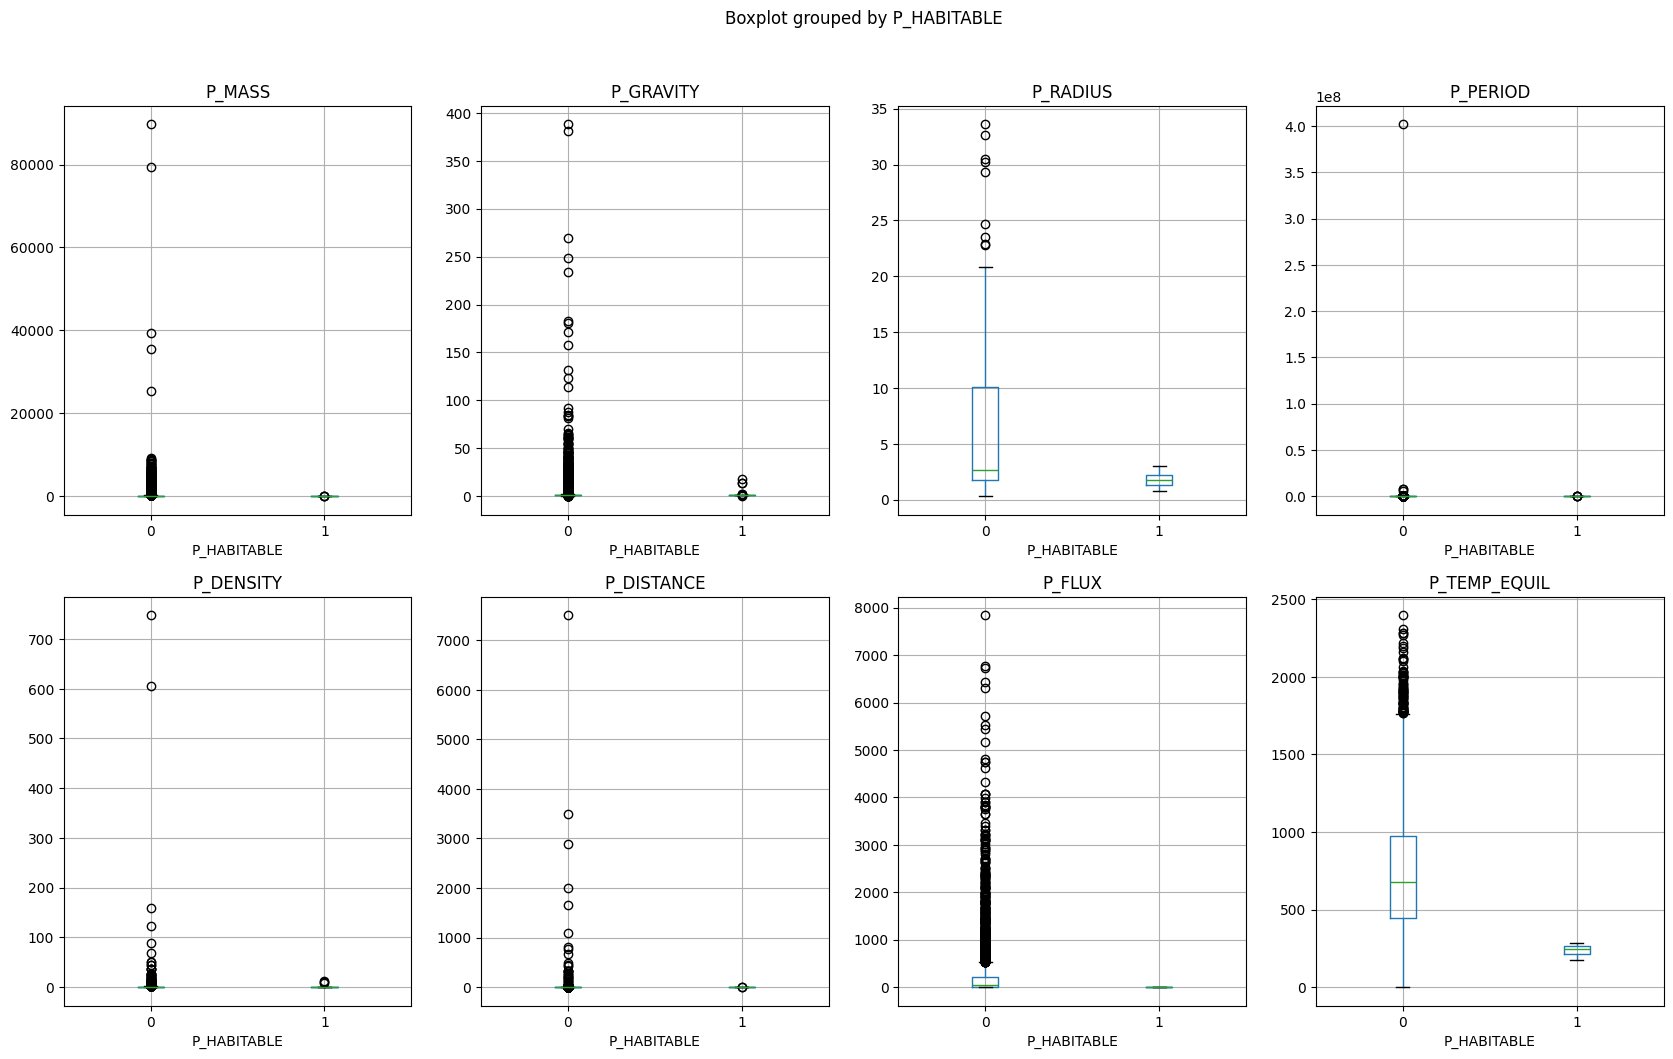

In [115]:
fig, axs = plt.subplots(2, 4, figsize=(20, 12), sharey=False) # Create subplots for each group of habitable planets
boxplot = df2.boxplot(column=['P_MASS', 'P_GRAVITY', 'P_RADIUS', 'P_PERIOD', 'P_DENSITY', 'P_DISTANCE', 'P_FLUX', 'P_TEMP_EQUIL'], by = 'P_HABITABLE', ax=axs, showfliers=True) # Create boxplots for each planetary parameter grouped by stellar type

C:\Users\ryanh\AppData\Local\Temp\ipykernel_28780\4237270406.py:2: UserWarning: When passing multiple axes, sharex and sharey are ignored. These settings must be specified when creating axes.
  boxplot2 = df2.boxplot(column=['P_MASS', 'P_GRAVITY', 'P_RADIUS', 'P_PERIOD', 'P_DENSITY', 'P_DISTANCE', 'P_FLUX', 'P_TEMP_EQUIL'], by = 'P_HABITABLE', ax=axs, showfliers=False) # Create boxplots for each planetary parameter grouped by stellar type without outliers


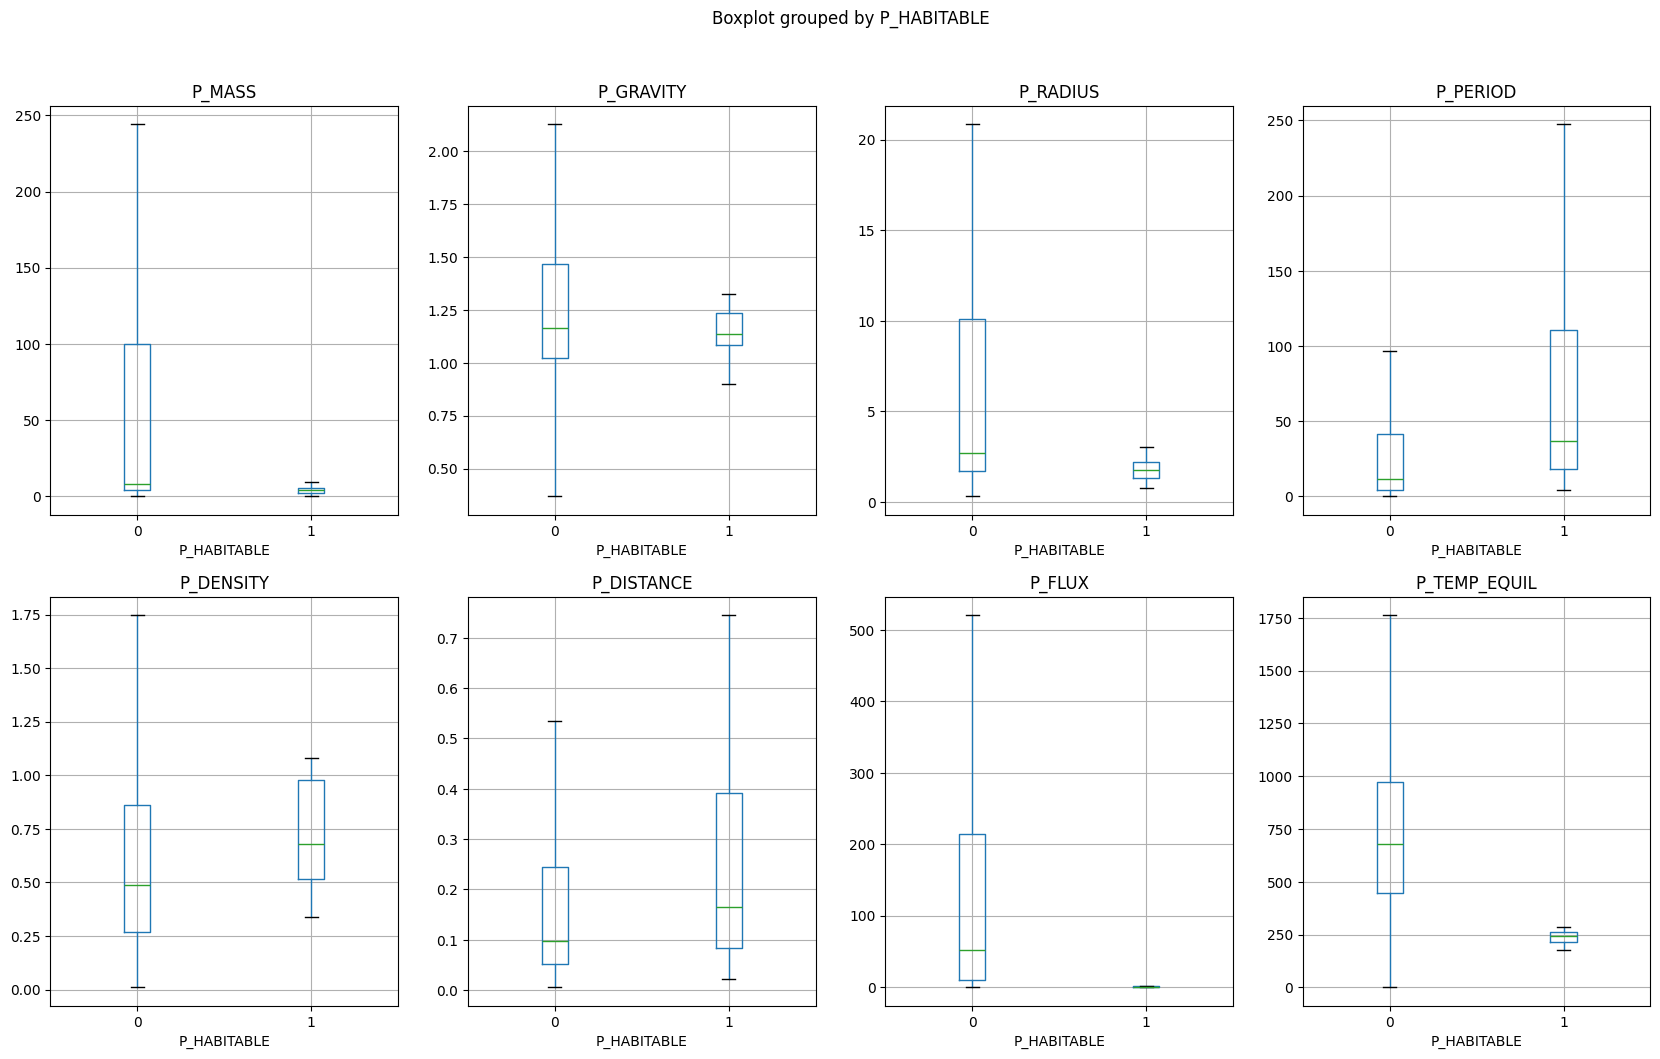

In [114]:
fig, axs = plt.subplots(2, 4, figsize=(20, 12), sharey=False) # Create subplots for each group of habitable planets
boxplot2 = df2.boxplot(column=['P_MASS', 'P_GRAVITY', 'P_RADIUS', 'P_PERIOD', 'P_DENSITY', 'P_DISTANCE', 'P_FLUX', 'P_TEMP_EQUIL'], by = 'P_HABITABLE', ax=axs, showfliers=False) # Create boxplots for each planetary parameter grouped by stellar type without outliers

C:\Users\ryanh\AppData\Local\Temp\ipykernel_28780\871534816.py:2: UserWarning: When passing multiple axes, sharex and sharey are ignored. These settings must be specified when creating axes.
  boxplot2 = df2.boxplot(column=['P_DENSITY', 'P_FLUX', 'P_TEMP_EQUIL'], by = 'P_HABITABLE', ax=axs, showfliers=False) # Create boxplots for each planetary parameter grouped by stellar type without outliers


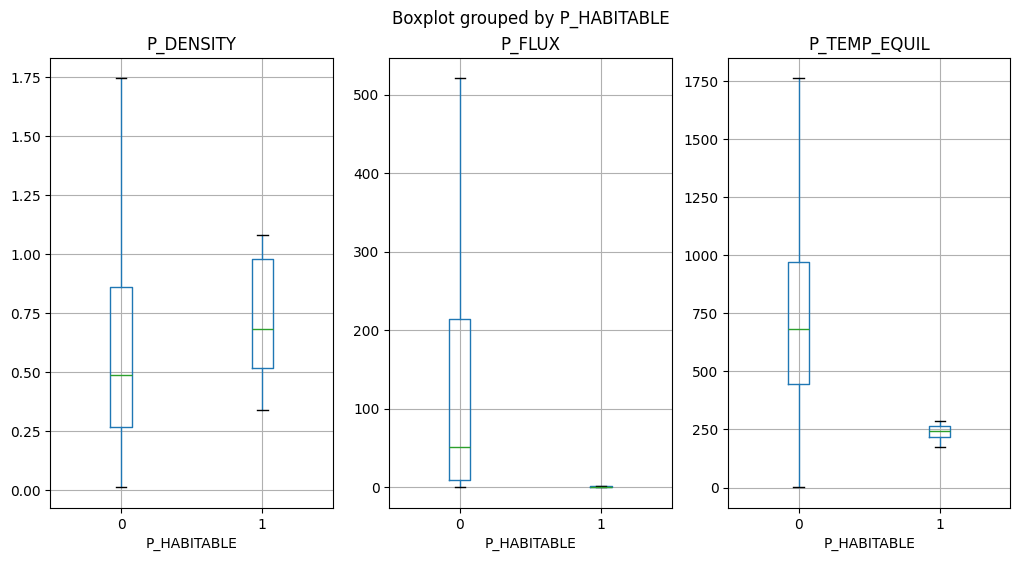

In [116]:
fig, axs = plt.subplots(1, 3, figsize=(12, 6), sharey=False) # Create subplots for each group of habitable planets
boxplot2 = df2.boxplot(column=['P_DENSITY', 'P_FLUX', 'P_TEMP_EQUIL'], by = 'P_HABITABLE', ax=axs, showfliers=False) # Create boxplots for each planetary parameter grouped by stellar type without outliers

Principle Component Analysis

In [95]:
X = df2.iloc[:, 1:9].values # Select the planetary parameters for PCA
y = df2.iloc[:, 30].values # Select the stellar type for PCA

df2.columns

Index(['P_NAME', 'P_MASS', 'P_RADIUS', 'P_PERIOD', 'P_GRAVITY', 'P_DENSITY',
       'P_DISTANCE', 'P_FLUX', 'P_TEMP_EQUIL', 'P_TEMP_SURF', 'P_TYPE',
       'P_TYPE_TEMP', 'S_NAME', 'S_TYPE_TEMP', 'S_RA', 'S_DEC', 'S_MAG',
       'S_TEMPERATURE', 'S_MASS', 'S_RADIUS', 'S_METALLICITY', 'S_LUMINOSITY',
       'S_HZ_OPT_MIN', 'S_HZ_OPT_MAX', 'S_HZ_CON_MIN', 'S_HZ_CON_MAX',
       'S_SNOW_LINE', 'S_ABIO_ZONE', 'P_HABZONE_OPT', 'P_HABZONE_CON',
       'P_HABITABLE', 'P_ESI'],
      dtype='object')

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaleStandard = StandardScaler() # Create a StandardScaler object to standardize the features
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X, y, test_size=0.2, random_state=42) # Split the dataset into training and testing sets

In [97]:
X_train_pca = scaleStandard.fit_transform(X_train_pca) # Fit the scaler to the training data and transform it
X_train_pca = pd.DataFrame(X_train_pca, columns=df2.columns[1:9]) # Convert the scaled training data back to a DataFrame

X_train_pca.describe().round(3) # Display summary statistics of the scaled training data

,P_MASS,P_RADIUS,P_PERIOD,P_GRAVITY,P_DENSITY,P_DISTANCE,P_FLUX,P_TEMP_EQUIL
count,3514.000,3514.000,3514.000,3514.000,3514.000,3514.000,3514.000,3514.000
mean,0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-0.158,-0.995,-0.017,-0.280,-0.090,-0.047,-0.423,-1.792
25%,-0.157,-0.705,-0.017,-0.206,-0.071,-0.047,-0.408,-0.727
50%,-0.155,-0.520,-0.017,-0.196,-0.054,-0.046,-0.338,-0.130
75%,-0.119,0.900,-0.017,-0.174,-0.026,-0.045,-0.069,0.584
max,37.213,5.795,59.259,28.262,55.649,47.704,12.924,4.115


In [98]:
pca1 = PCA()
X_pca1 = pca1.fit_transform(X_train_pca) # Fit PCA to the scaled training data and transform it
pca1.explained_variance_ratio_

array([0.25216098, 0.2194293 , 0.21047385, 0.15137037, 0.08569917,
       0.03041934, 0.02714749, 0.0232995 ])

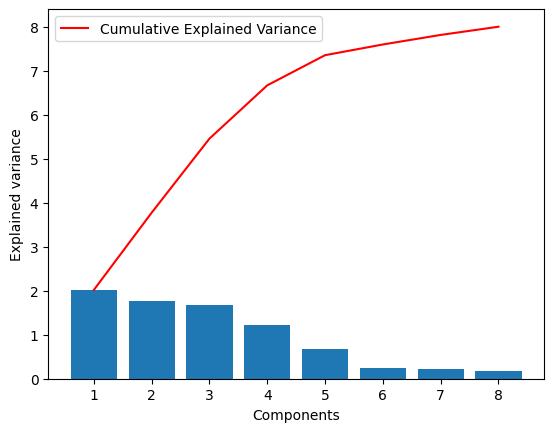

In [99]:
plt.bar(range(1,len(pca1.explained_variance_ )+1),pca1.explained_variance_ )
plt.ylabel('Explained variance')
plt.xlabel('Components')
plt.plot(range(1,len(pca1.explained_variance_ )+1),
         np.cumsum(pca1.explained_variance_),
         c='red',
         label="Cumulative Explained Variance")
plt.legend(loc='upper left')

In [100]:
pca2 = PCA(0.90) # Create a PCA object that retains 90% of the variance
X_pca2 = pca2.fit_transform(X_train_pca) # Fit PCA to the scaled data
X_pca2.shape # Display the shape of the transformed data

(3514, 5)

In [101]:
pca2c = PCA(n_components=2) # Create a PCA object that retains 2 components
X_pca2c = pca2c.fit_transform(X_train_pca) # Fit PCA to the scaled training data and transform it to 2 components

In [102]:
colormap = plt.colormaps.get_cmap('coolwarm') # Define a colormap for the scatter plot
encoded_y_train = pd.Series(y_train_pca).astype('category').cat.codes # Encode the categorical target variable for coloring

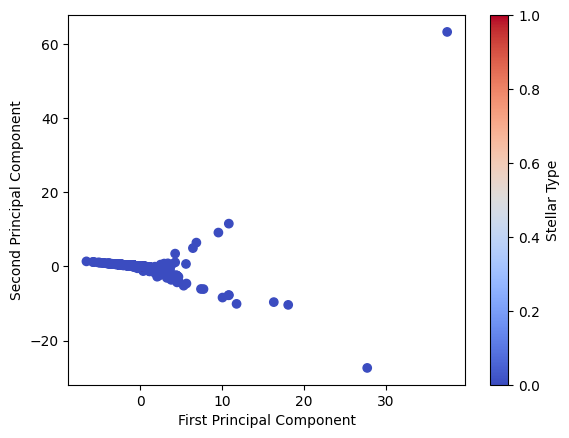

In [103]:
plt.figure()
ax = plt.gca()
scatter = plt.scatter(X_pca2c[:, 0], X_pca2c[:, 1], c=encoded_y_train, cmap=colormap) # Create a scatter plot of the first two principal components colored by stellar type
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.colorbar(scatter, label='Stellar Type')
plt.show()

Linear Discriminant Analysis

In [104]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [105]:
scaleStandard = StandardScaler() # Create a StandardScaler object to standardize the features
X = df2.iloc[:, 1:9].values # Select the planetary parameters for PCA
y = df2.iloc[:, 30].values # Select the stellar type for PCA

X = scaleStandard.fit_transform(X) # Fit the scaler to the training data and transform it
X_train_lda, X_test_lda, y_train_lda, y_test_lda = train_test_split(X, y, test_size=0.2, random_state=42) # Split the dataset into training and testing sets
X_train_lda = pd.DataFrame(X_train_lda, columns=df2.columns[1:9]) # Convert the scaled training data back to a DataFrame
X_test_lda = pd.DataFrame(X_test_lda, columns=df2.columns[1:9]) # Convert the scaled testing data back to a DataFrame

X_train_lda.describe().round(3) # Display summary statistics of the scaled training data

,P_MASS,P_RADIUS,P_PERIOD,P_GRAVITY,P_DENSITY,P_DISTANCE,P_FLUX,P_TEMP_EQUIL
count,3514.000,3514.000,3514.000,3514.000,3514.000,3514.000,3514.000,3514.000
mean,0.005,-0.006,0.003,0.003,-0.002,0.006,0.008,-0.000
std,1.083,1.000,1.118,0.948,0.889,1.111,1.031,1.006
min,-0.167,-1.001,-0.016,-0.263,-0.082,-0.046,-0.428,-1.801
25%,-0.165,-0.711,-0.016,-0.193,-0.065,-0.046,-0.413,-0.731
50%,-0.163,-0.526,-0.016,-0.183,-0.051,-0.046,-0.341,-0.131
75%,-0.124,0.894,-0.016,-0.162,-0.026,-0.045,-0.063,0.587
max,40.284,5.790,66.241,26.789,49.457,53.019,13.331,4.137


In [106]:
lda = LDA(n_components=1) # Create an LDA object that retains 1 component
X_lda = lda.fit_transform(X_train_lda, y_train_lda) # Fit LDA to the scaled training data and transform it to 1 component

df_lda = pd.DataFrame({'LDA1': X_lda[:, 0], 'stellar_type': y_train_lda}, columns=['LDA1', 'stellar_type']) # Convert the LDA transformed data to a DataFrame
display(df_lda.head(10)) # Display the first 10 rows of the LDA transformed data

,LDA1,stellar_type
0,0.150491,0
1,-0.190833,0
2,0.508141,0
3,0.839883,0
4,-1.910592,0
5,0.613948,0
6,-0.156679,0
7,0.291874,0
8,-1.868797,0
9,0.724503,0


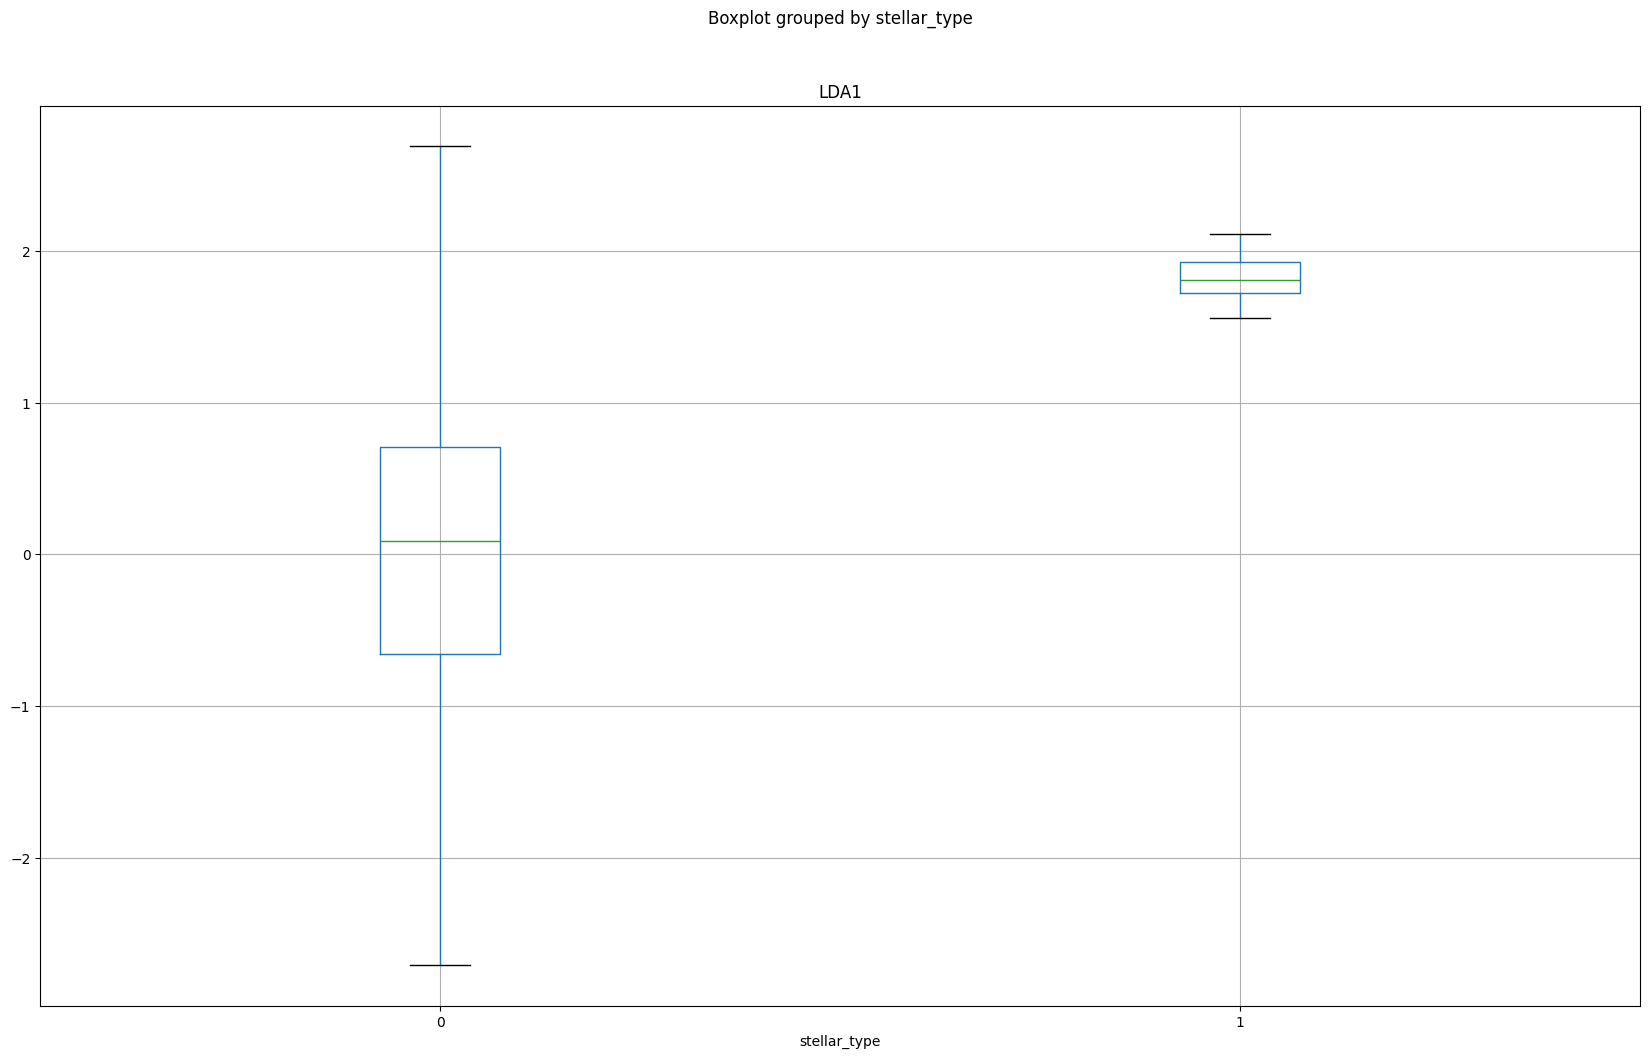

In [107]:
fig, axs = plt.subplots(1, 1, figsize=(20, 12), sharey=False)
boxplot = df_lda.boxplot(column=['LDA1'], by = 'stellar_type', ax=axs, showfliers=False) # Create boxplots for the LDA transformed data grouped by stellar type

In [108]:
import plotly.express as px

In [109]:
fig = px.histogram(df_lda, x='LDA1', color='stellar_type', barmode='overlay', nbins=100, title='Distribution of LDA1 by Stellar Type')
fig.update_traces(opacity=0.75) # Set the opacity of the bars for better visibility
fig.show() # Display the histogram

In [110]:
y_pred_lda = lda.predict(X_test_lda) # Predict the stellar type for the test set using LDA

print(classification_report(y_test_lda, y_pred_lda)) # Print the classification report
print(confusion_matrix(y_test_lda, y_pred_lda)) # Print the confusion matrix

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       866
           1       0.00      0.00      0.00        13

    accuracy                           0.98       879
   macro avg       0.49      0.50      0.50       879
weighted avg       0.97      0.98      0.98       879

[[865   1]
 [ 13   0]]


Quadratic discriminant analysis

In [111]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

In [112]:
scaleStandard = StandardScaler() # Create a StandardScaler object to standardize the features
X = df2.iloc[:, 1:9].values # Select the planetary parameters for PCA
y = df2.iloc[:, 30].values # Select the stellar type for PCA

X = scaleStandard.fit_transform(X) # Fit the scaler to the training data and transform it
X_train_qda, X_test_qda, y_train_qda, y_test_qda = train_test_split(X, y, test_size=0.2, random_state=42) # Split the dataset into training and testing sets
X_train_qda = pd.DataFrame(X_train_qda, columns=df2.columns[1:9]) # Convert the scaled training data back to a DataFrame
X_test_qda = pd.DataFrame(X_test_qda, columns=df2.columns[1:9]) # Convert the scaled testing data back to a DataFrame

X_train_qda.describe().round(3) # Display summary statistics of the scaled training data

,P_MASS,P_RADIUS,P_PERIOD,P_GRAVITY,P_DENSITY,P_DISTANCE,P_FLUX,P_TEMP_EQUIL
count,3514.000,3514.000,3514.000,3514.000,3514.000,3514.000,3514.000,3514.000
mean,0.005,-0.006,0.003,0.003,-0.002,0.006,0.008,-0.000
std,1.083,1.000,1.118,0.948,0.889,1.111,1.031,1.006
min,-0.167,-1.001,-0.016,-0.263,-0.082,-0.046,-0.428,-1.801
25%,-0.165,-0.711,-0.016,-0.193,-0.065,-0.046,-0.413,-0.731
50%,-0.163,-0.526,-0.016,-0.183,-0.051,-0.046,-0.341,-0.131
75%,-0.124,0.894,-0.016,-0.162,-0.026,-0.045,-0.063,0.587
max,40.284,5.790,66.241,26.789,49.457,53.019,13.331,4.137


In [113]:
qda = QDA() # Create an QDA object that retains 1 component
X_qda = qda.fit(X_train_qda, y_train_qda) # Fit QDA to the scaled training data and transform it to 1 component

y_pred_qda = qda.predict(X_test_qda) # Predict the stellar type for the test set using QDA

print(classification_report(y_test_qda, y_pred_qda)) # Print the classification report
print(confusion_matrix(y_test_qda, y_pred_qda)) # Print the confusion matrix

#df_qda = pd.DataFrame({'QDA1': X_qda[:, 0], 'stellar_type': y_train}, columns=['QDA1', 'stellar_type']) # Convert the QDA transformed data to a DataFrame
#display(df_qda.head(10)) # Display the first 10 rows of the QDA transformed data

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       866
           1       0.44      0.92      0.60        13

    accuracy                           0.98       879
   macro avg       0.72      0.95      0.80       879
weighted avg       0.99      0.98      0.98       879

[[851  15]
 [  1  12]]


C:\Users\ryanh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
